# Końcowy trening i ocena pipeline'u klasyfikacji znaków drogowych

Celem eksperymentu jest przeprowadzenie pełnego treningu oraz końcowej oceny wybranego pipeline'u klasyfikacji znaków drogowych.

Na podstawie wcześniejszych eksperymentów wybrano następującą konfigurację:

- `ResNet50` z wagami ImageNet,
- `WeightedRandomSampler`,
- augmentacja oświetleniowa,
- korekcja gamma γ = 1.5,
- funkcja straty Cross Entropy.

Konfiguracja augmentacji oświetleniowej obejmuje:

- zakres jasności: 0.3–1.3,
- zakres kontrastu: 0.8–1.2,
- prawdopodobieństwo zastosowania: 0.8.

Model jest trenowany w dwóch etapach:

1. trening przy zamrożonym backbone przez 10 epok,
2. fine-tuning przez 5 epok.

Po zakończeniu treningu model jest oceniany na niezależnym zbiorze `test_final`.

Ocena obejmuje obraz oryginalny, trzy poziomy kontrolowanego zaciemnienia oraz trzy poziomy zwiększonej jasności.

Zbiór `test_final` nie jest wykorzystywany do wyboru hiperparametrów ani dalszego dostrajania modelu.

In [ ]:
from pathlib import Path
import sys
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.preprocessing import (
    gamma_correction,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)


HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "final_pipeline"
)


FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja finalnego pipeline'u

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 10
FINE_TUNE_EPOCHS = 5
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True
GAMMA_VALUE = 1.5

BRIGHTNESS_RANGE = (
    0.3,
    1.3,
)

CONTRAST_RANGE = (
    0.8,
    1.2,
)

AUGMENTATION_PROBABILITY = 0.8

LIGHTING_VARIANTS = [
    "original",
    "dark_1",
    "dark_2",
    "dark_3",
    "bright_1",
    "bright_2",
    "bright_3",
]


CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "final_resnet50_pipeline_best.pt"
)


print(
    "Input:",
    IMAGE_SIZE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Frozen epochs:",
    FROZEN_EPOCHS
)

print(
    "Fine-tune epochs:",
    FINE_TUNE_EPOCHS
)

print(
    "Frozen LR:",
    FROZEN_LR
)

print(
    "Fine-tune LR:",
    FINE_TUNE_LR
)

print(
    "Gamma:",
    GAMMA_VALUE
)

print(
    "Brightness range:",
    BRIGHTNESS_RANGE
)

print(
    "Contrast range:",
    CONTRAST_RANGE
)

print(
    "Augmentation probability:",
    AUGMENTATION_PROBABILITY
)

Input: 224
Batch size: 32
Frozen epochs: 10
Fine-tune epochs: 5
Frozen LR: 0.001
Fine-tune LR: 1e-05
Gamma: 1.5
Brightness range: (0.3, 1.3)
Contrast range: (0.8, 1.2)
Augmentation probability: 0.8


## 2. Wczytanie manifestów danych

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacje treningowe

Podczas treningu stosowana jest losowa augmentacja jasności i kontrastu.

Korekcja gamma γ = 1.5 jest wykonywana po augmentacji oświetleniowej.

Transformacja geometryczna w postaci niewielkiej losowej rotacji jest zachowana jako element podstawowego przygotowania danych.

In [4]:
normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_final_train_transform():

    transform_list = [
        RandomLightingAugmentation(
            brightness_range=BRIGHTNESS_RANGE,
            contrast_range=CONTRAST_RANGE,
            probability=(
                AUGMENTATION_PROBABILITY
            ),
        ),

        transforms.Lambda(
            lambda image:
            gamma_correction(
                image,
                gamma=GAMMA_VALUE,
            )
        ),

        transforms.Resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE,
            )
        ),

        transforms.RandomRotation(
            10
        ),

        transforms.ToTensor(),

        normalization,
    ]


    return transforms.Compose(
        transform_list
    )

## 4. Transformacja walidacyjna

Podczas walidacji nie jest stosowana losowa augmentacja.


In [5]:
def build_final_eval_transform():

    return transforms.Compose(
        [
            transforms.Lambda(
                lambda image:
                gamma_correction(
                    image,
                    gamma=GAMMA_VALUE,
                )
            ),

            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )

## 5. DataLoadery treningowe

In [6]:
train_dataset = (
    TrafficSignDataset(
        TRAIN_PATH,
        class_to_idx,
        transform=(
            build_final_train_transform()
        ),
    )
)


validation_dataset = (
    TrafficSignDataset(
        VALIDATION_PATH,
        class_to_idx,
        transform=(
            build_final_eval_transform()
        ),
    )
)


weighted_sampler = (
    build_weighted_sampler(
        TRAIN_PATH
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


print(
    "TRAIN:",
    len(train_dataset)
)

print(
    "VALIDATION:",
    len(validation_dataset)
)

TRAIN: 14232
VALIDATION: 2512


## 6. Wizualizacja finalnej transformacji treningowej

Przed rozpoczęciem treningu przedstawiono kilka realizacji finalnej augmentacji oświetleniowej i korekcji gamma dla tego samego obrazu.

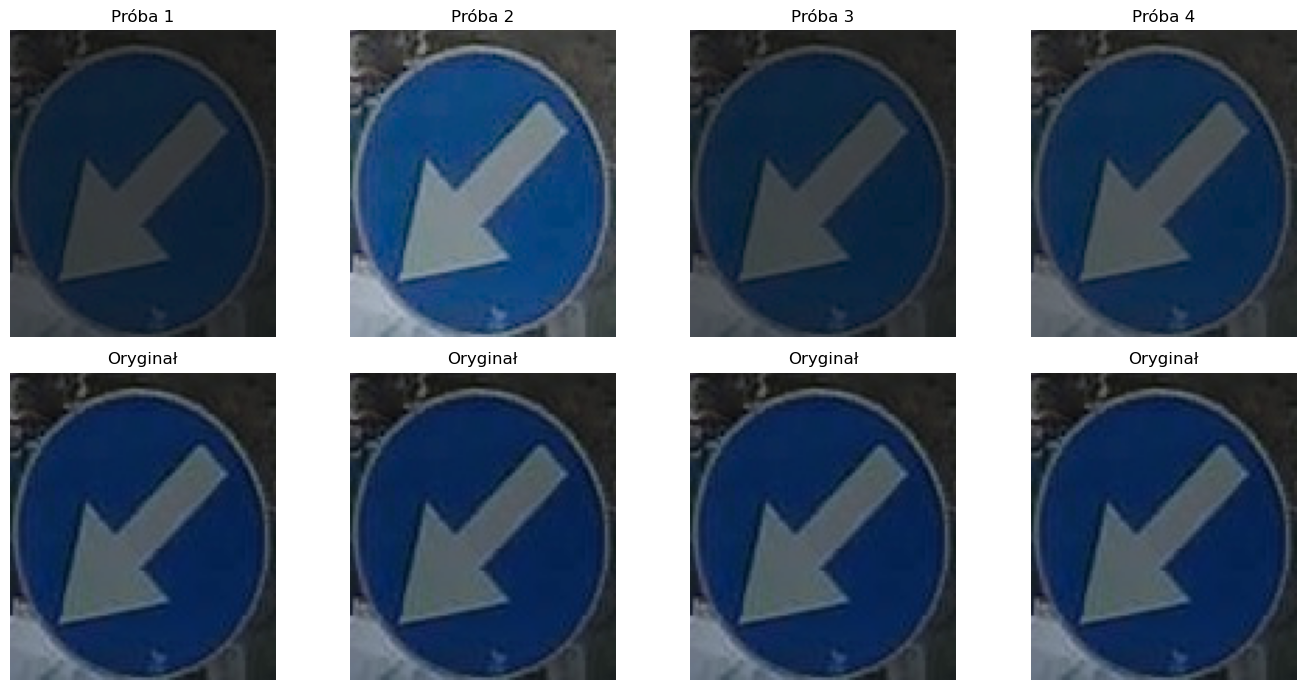

In [7]:
sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)


for col_index in range(4):

    lighting = (
        RandomLightingAugmentation(
            brightness_range=(
                BRIGHTNESS_RANGE
            ),
            contrast_range=(
                CONTRAST_RANGE
            ),
            probability=1.0,
        )
    )


    image = lighting(
        sample_image
    )


    image = gamma_correction(
        image,
        gamma=GAMMA_VALUE,
    )


    axes[
        0,
        col_index
    ].imshow(
        image
    )


    axes[
        0,
        col_index
    ].set_title(
        f"Próba {col_index + 1}"
    )


    axes[
        0,
        col_index
    ].axis(
        "off"
    )


    axes[
        1,
        col_index
    ].imshow(
        sample_image
    )


    axes[
        1,
        col_index
    ].set_title(
        "Oryginał"
    )


    axes[
        1,
        col_index
    ].axis(
        "off"
    )


axes[
    0,
    0
].set_ylabel(
    "Finalny pipeline",
    fontsize=11,
)


axes[
    1,
    0
].set_ylabel(
    "Obraz wejściowy",
    fontsize=11,
)


plt.tight_layout()
plt.show()

## 7. Utworzenie modelu ResNet50

In [8]:
model = create_resnet50(
    num_classes=len(
        class_codes
    ),
    pretrained=PRETRAINED,
)


model = (
    freeze_resnet50_backbone(
        model
    )
)


model = model.to(
    DEVICE
)


print(
    "Model:",
    "ResNet50"
)

print(
    "Liczba klas:",
    len(class_codes)
)

Model: ResNet50
Liczba klas: 92


## 8. Trening głowicy klasyfikacyjnej

Backbone modelu jest zamrożony.

W tym etapie uczona jest głowica klasyfikacyjna przez 10 epok.

In [9]:
criterion = (
    nn.CrossEntropyLoss()
)


optimizer = torch.optim.Adam(
    filter(
        lambda parameter:
        parameter.requires_grad,
        model.parameters(),
    ),
    lr=FROZEN_LR,
)


frozen_checkpoint = (
    CHECKPOINT_DIR
    / "final_resnet50_pipeline_frozen_best.pt"
)


frozen_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=FROZEN_EPOCHS,
    checkpoint_path=frozen_checkpoint,
)

Postęp treningu:   0%|          | 0/10 [00:00<?, ?it/s]

Epoka 1/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/10:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 6/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 7/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 8/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 9/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 10/10:   0%|          | 0/445 [00:00<?, ?it/s]

## 9. Fine-tuning modelu

Po zakończeniu pierwszej fazy treningu odblokowana zostaje końcowa część backbone modelu.

Fine-tuning jest wykonywany przez 5 epok z mniejszym współczynnikiem uczenia.

In [10]:
model = (
    unfreeze_resnet50_last_block(
        model
    )
)


optimizer = torch.optim.Adam(
    filter(
        lambda parameter:
        parameter.requires_grad,
        model.parameters(),
    ),
    lr=FINE_TUNE_LR,
)


fine_tune_checkpoint = (
    CHECKPOINT_DIR
    / "final_resnet50_pipeline_best.pt"
)


fine_tune_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=FINE_TUNE_EPOCHS,
    checkpoint_path=fine_tune_checkpoint,
)


model.eval()

Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 10. Zapis informacji o treningu

In [11]:
training_summary = {
    "model":
        "ResNet50",

    "pretrained":
        PRETRAINED,

    "balancing":
        "weighted_sampler",

    "loss":
        "CrossEntropyLoss",

    "gamma":
        GAMMA_VALUE,

    "brightness_range":
        BRIGHTNESS_RANGE,

    "contrast_range":
        CONTRAST_RANGE,

    "augmentation_probability":
        AUGMENTATION_PROBABILITY,

    "frozen_epochs":
        FROZEN_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "frozen_learning_rate":
        FROZEN_LR,

    "fine_tune_learning_rate":
        FINE_TUNE_LR,
}


(
    HISTORIES_DIR
    / "final_pipeline_training_config.json"
).write_text(
    json.dumps(
        training_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        training_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "model": "ResNet50",
  "pretrained": true,
  "balancing": "weighted_sampler",
  "loss": "CrossEntropyLoss",
  "gamma": 1.5,
  "brightness_range": [
    0.3,
    1.3
  ],
  "contrast_range": [
    0.8,
    1.2
  ],
  "augmentation_probability": 0.8,
  "frozen_epochs": 10,
  "fine_tune_epochs": 5,
  "frozen_learning_rate": 0.001,
  "fine_tune_learning_rate": 1e-05
}


## 11. Standardowa skuteczność na zbiorze walidacyjnym

Przed przejściem do niezależnego zbioru testowego sprawdzana jest skuteczność finalnego modelu na zbiorze walidacyjnym.

In [12]:
validation_true, validation_pred, validation_time = (
    predict(
        model,
        validation_loader,
        DEVICE,
    )
)


validation_metrics = (
    evaluate_predictions(
        validation_true,
        validation_pred,
    )
)


validation_results = {
    "accuracy":
        validation_metrics[
            "accuracy"
        ],

    "macro_precision":
        validation_metrics[
            "macro_precision"
        ],

    "macro_recall":
        validation_metrics[
            "macro_recall"
        ],

    "macro_f1":
        validation_metrics[
            "macro_f1"
        ],

    "inference_time_seconds":
        validation_time,
}


print(
    json.dumps(
        validation_results,
        indent=2,
    )
)

{
  "accuracy": 0.9323248407643312,
  "macro_precision": 0.9279378192524976,
  "macro_recall": 0.9391786287487985,
  "macro_f1": 0.9302428707519097,
  "inference_time_seconds": 201.86491779999778
}


## 12. Przygotowanie funkcji do końcowej oceny warunków oświetleniowych

In [13]:
def evaluate_test_variant(
    variant,
):

    dataset = (
        ControlledLightingDataset(
            TEST_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=(
                build_final_eval_transform()
            ),
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "variant":
            variant,

        "factor":
            LIGHTING_FACTORS[
                variant
            ],

        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,

        "y_true":
            y_true,

        "y_pred":
            y_pred,
    }

## 13. Końcowy test niezależny

Model jest oceniany na całym zbiorze `test_final` dla obrazu oryginalnego, kontrolowanego zaciemnienia oraz kontrolowanego zwiększenia jasności.

Dla każdego wariantu stosowana jest korekcja gamma γ = 1.5.

In [20]:
test_results = []


for variant in LIGHTING_VARIANTS:

    print(
        f"TEST_FINAL | {variant}"
    )


    result = evaluate_test_variant(
        variant
    )


    test_results.append(
        result
    )


final_test_df = pd.DataFrame(
    [
        {
            key: value
            for key, value
            in result.items()
            if key not in [
                "y_true",
                "y_pred",
            ]
        }
        for result
        in test_results
    ]
)


display(
    final_test_df
)

TEST_FINAL | original
TEST_FINAL | dark_1
TEST_FINAL | dark_2
TEST_FINAL | dark_3
TEST_FINAL | bright_1
TEST_FINAL | bright_2
TEST_FINAL | bright_3


,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,1.0,4298,0.898325,0.877983,0.888718,0.875451,370.243851
1,dark_1,0.7,4298,0.893439,0.870550,0.884020,0.870243,377.748287
2,dark_2,0.5,4298,0.891577,0.871409,0.883576,0.870876,368.321308
3,dark_3,0.3,4298,0.888087,0.872363,0.880038,0.867828,363.696348
4,bright_1,1.3,4298,0.901117,0.877070,0.889115,0.876889,364.973791
5,bright_2,1.6,4298,0.886691,0.861773,0.873637,0.860631,366.611216
6,bright_3,2.0,4298,0.861564,0.826335,0.841320,0.820452,361.664745


## 14. Podsumowanie wyników dla zaciemnienia

In [21]:
dark_test_df = (
    final_test_df[
        final_test_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
)


mean_dark_macro_f1 = (
    dark_test_df[
        "macro_f1"
    ].mean()
)


mean_dark_accuracy = (
    dark_test_df[
        "accuracy"
    ].mean()
)


dark3_macro_f1 = (
    dark_test_df[
        dark_test_df[
            "variant"
        ] == "dark_3"
    ]["macro_f1"].iloc[0]
)


original_macro_f1 = (
    final_test_df[
        final_test_df[
            "variant"
        ] == "original"
    ]["macro_f1"].iloc[0]
)


f1_drop_to_dark3 = (
    original_macro_f1
    -
    dark3_macro_f1
)


dark_summary = pd.DataFrame(
    [
        {
            "mean_dark_macro_f1":
                mean_dark_macro_f1,

            "mean_dark_accuracy":
                mean_dark_accuracy,

            "dark3_macro_f1":
                dark3_macro_f1,

            "original_macro_f1":
                original_macro_f1,

            "f1_drop_to_dark3":
                f1_drop_to_dark3,
        }
    ]
)


display(
    dark_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,original_macro_f1,f1_drop_to_dark3
0,0.869649,0.891035,0.867828,0.875451,0.007623


## 15. Ocena warunków zwiększonej jasności

Wyniki dla `bright_1`, `bright_2` i `bright_3` umożliwiają ocenę zachowania modelu również w warunkach prześwietlenia.

In [22]:
bright_test_df = (
    final_test_df[
        final_test_df[
            "variant"
        ].isin(
            [
                "bright_1",
                "bright_2",
                "bright_3",
            ]
        )
    ]
)


display(
    bright_test_df
)

,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
4,bright_1,1.3,4298,0.901117,0.877070,0.889115,0.876889,364.973791
5,bright_2,1.6,4298,0.886691,0.861773,0.873637,0.860631,366.611216
6,bright_3,2.0,4298,0.861564,0.826335,0.841320,0.820452,361.664745


## 16. Porównanie wyników dla wszystkich warunków oświetleniowych

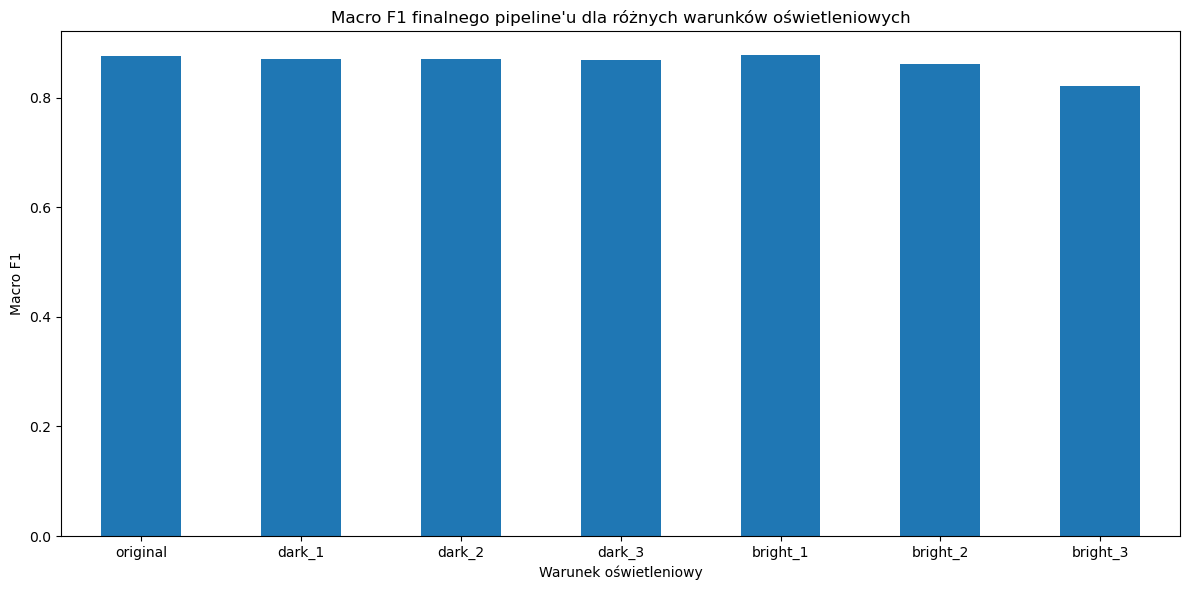

In [23]:
plot_df = (
    final_test_df[
        [
            "variant",
            "macro_f1",
        ]
    ]
)


fig, ax = plt.subplots(
    figsize=(12, 6)
)


plot_df.plot(
    x="variant",
    y="macro_f1",
    kind="bar",
    ax=ax,
    legend=False,
)


ax.set_title(
    "Macro F1 finalnego pipeline'u "
    "dla różnych warunków oświetleniowych"
)

ax.set_xlabel(
    "Warunek oświetleniowy"
)

ax.set_ylabel(
    "Macro F1"
)


plt.xticks(
    rotation=0
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_final_pipeline_macro_f1.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 17. Macierz pomyłek dla obrazu oryginalnego

Macierz pomyłek przedstawia rozkład poprawnych i błędnych klasyfikacji dla oryginalnych obrazów zbioru `test_final`.

In [24]:
original_test_result = next(
    result
    for result
    in test_results
    if result[
        "variant"
    ] == "original"
)


y_true_original = (
    original_test_result[
        "y_true"
    ]
)


y_pred_original = (
    original_test_result[
        "y_pred"
    ]
)


cm_original = confusion_matrix(
    y_true_original,
    y_pred_original,
    labels=list(
        range(
            len(class_codes)
        )
    ),
)


cm_original_df = pd.DataFrame(
    cm_original,
    index=class_codes,
    columns=class_codes,
)


display(
    cm_original_df
)

,A-1,A-11,A-11a,A-12a,A-14,A-15,A-16,A-17,A-18b,A-2,...,D-52,D-53,D-6,D-6b,D-7,D-8,D-9,D-tablica,G-1a,G-3
A-1,39,0,0,0,0,0,0,0,1,6,...,0,0,0,0,0,0,0,0,0,0
A-11,0,10,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
A-11a,0,1,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A-12a,0,0,0,18,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
A-14,0,0,0,0,8,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D-8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,33,0,0,0,0
D-9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,8,0,0,0
D-tablica,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,15,0,0
G-1a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,11,0


## 18. Wizualizacja macierzy pomyłek — obraz oryginalny

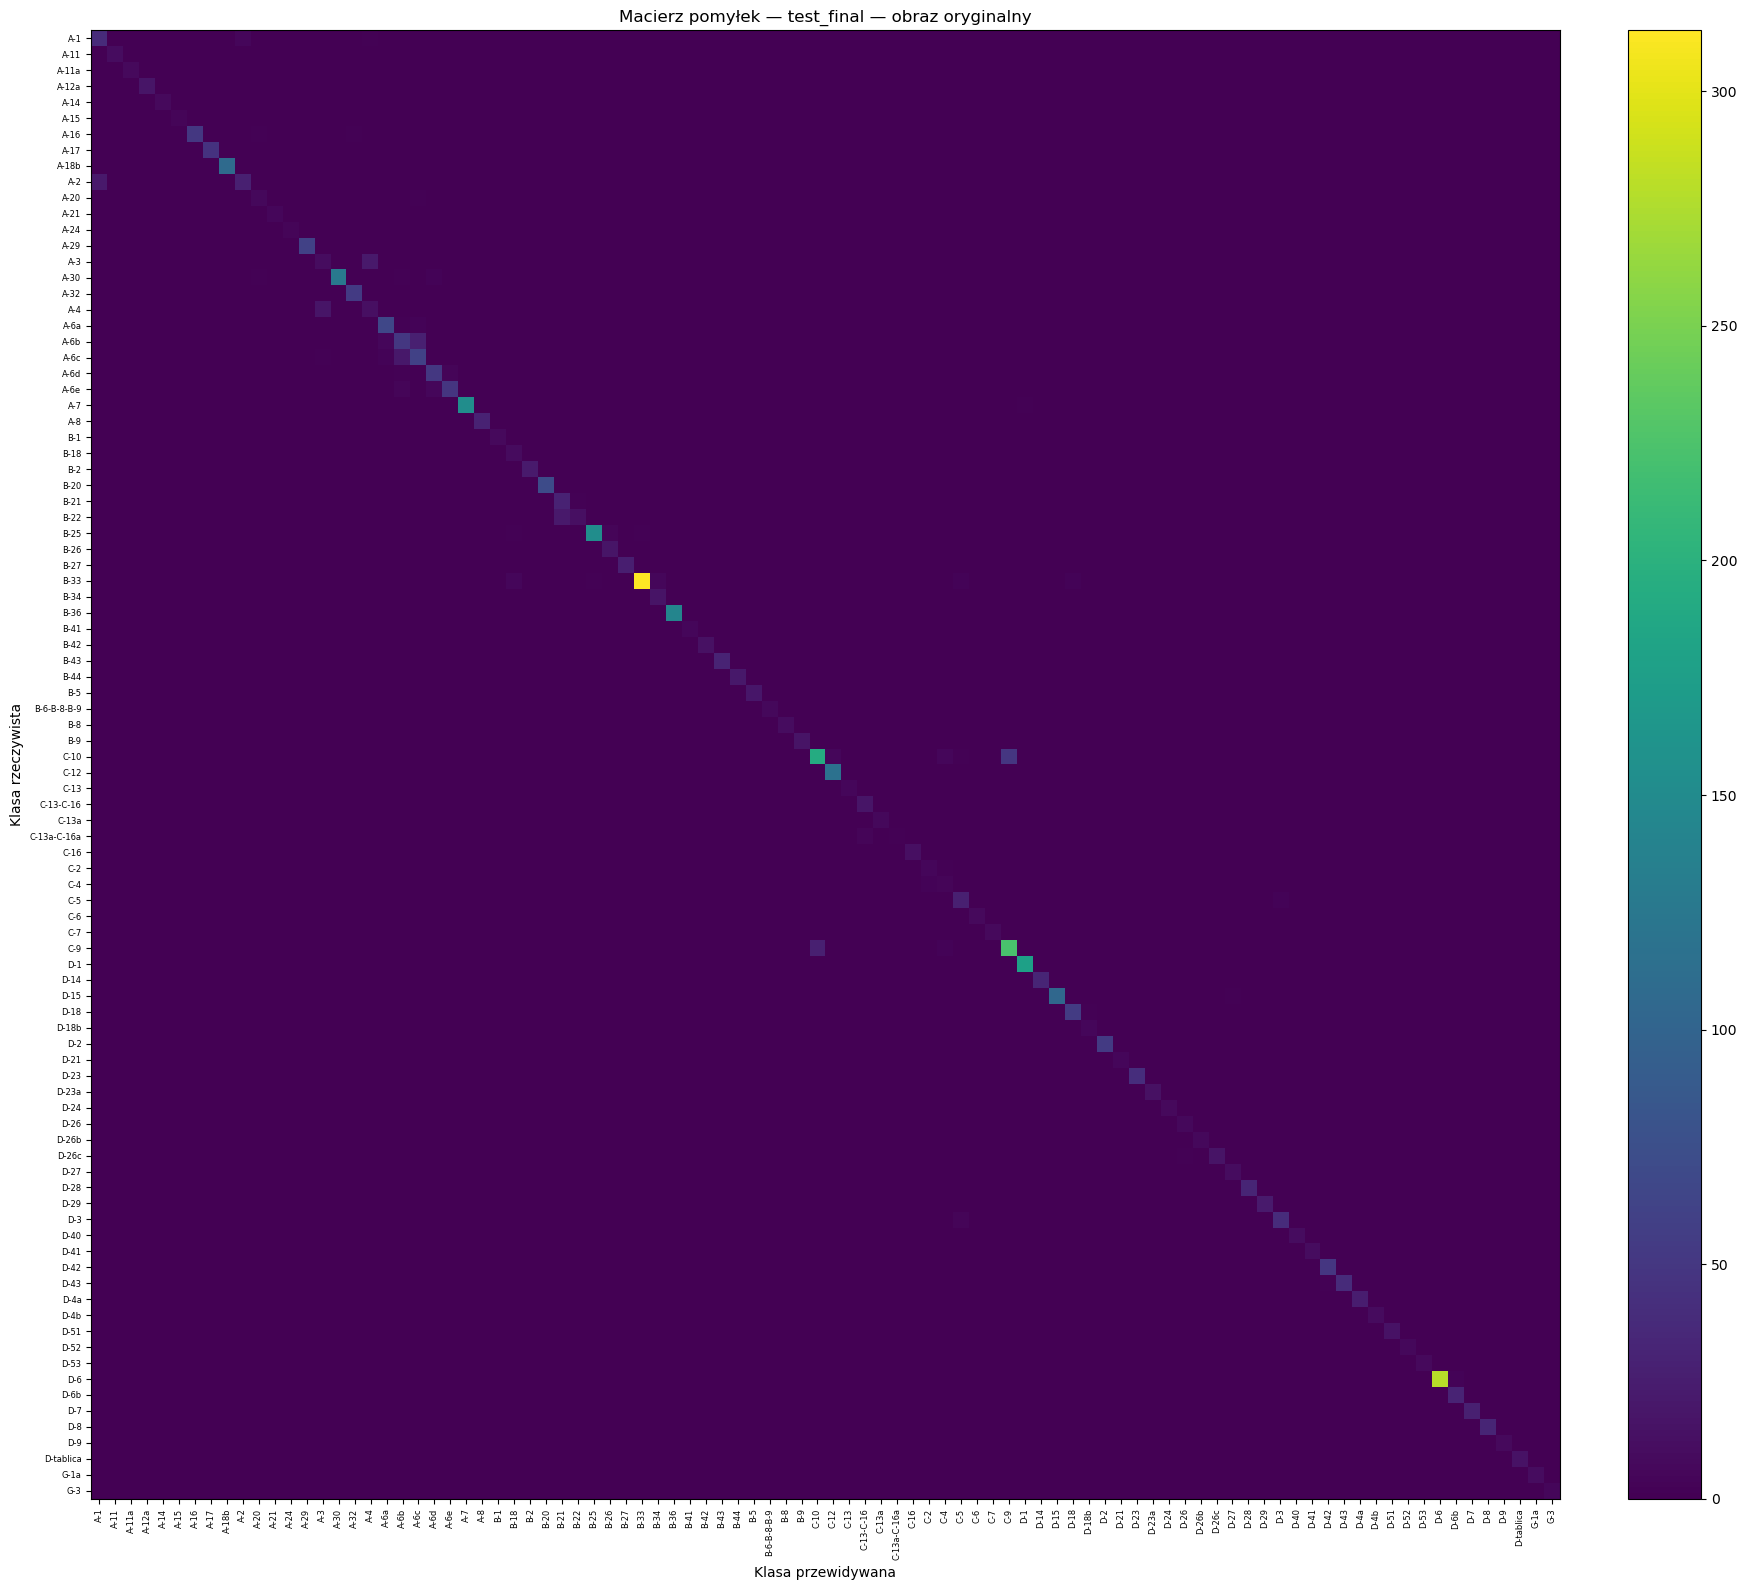

In [25]:
fig, ax = plt.subplots(
    figsize=(18, 16)
)


image = ax.imshow(
    cm_original,
    interpolation="nearest",
)


ax.set_title(
    "Macierz pomyłek — test_final — obraz oryginalny"
)

ax.set_xlabel(
    "Klasa przewidywana"
)

ax.set_ylabel(
    "Klasa rzeczywista"
)


plt.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)


ax.set_xticks(
    range(
        len(class_codes)
    )
)

ax.set_yticks(
    range(
        len(class_codes)
    )
)


ax.set_xticklabels(
    class_codes,
    rotation=90,
    fontsize=6,
)

ax.set_yticklabels(
    class_codes,
    fontsize=6,
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_confusion_matrix_original.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 19. Macierz pomyłek dla `dark_3`

Macierz pomyłek dla najsilniejszego zaciemnienia umożliwia identyfikację klas najbardziej podatnych na błędną klasyfikację w trudnych warunkach oświetleniowych.

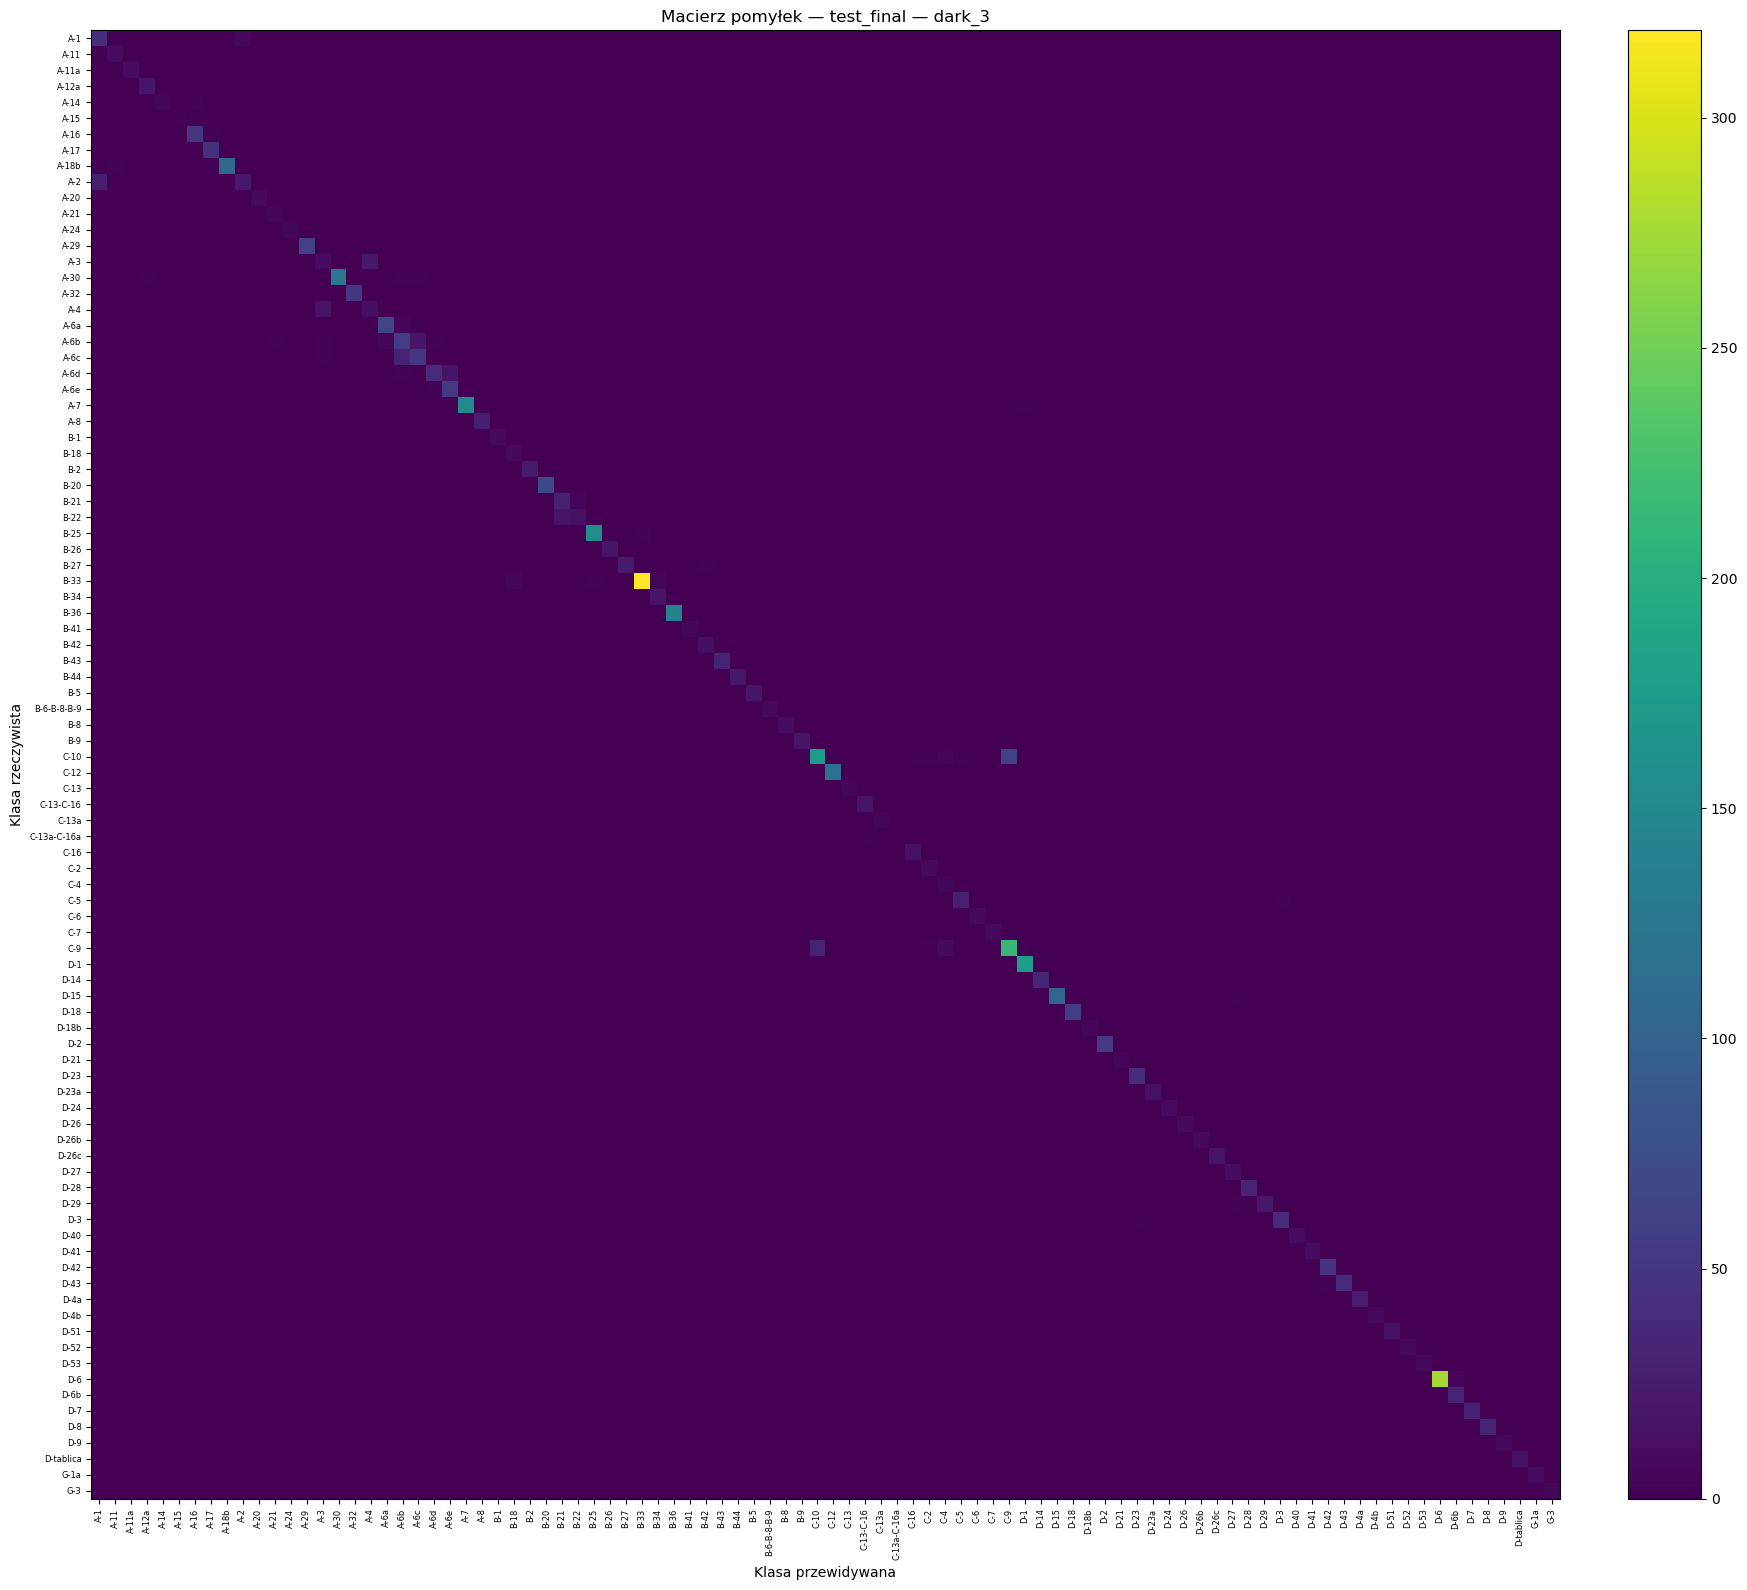

In [26]:
dark3_test_result = next(
    result
    for result
    in test_results
    if result[
        "variant"
    ] == "dark_3"
)


y_true_dark3 = (
    dark3_test_result[
        "y_true"
    ]
)


y_pred_dark3 = (
    dark3_test_result[
        "y_pred"
    ]
)


cm_dark3 = confusion_matrix(
    y_true_dark3,
    y_pred_dark3,
    labels=list(
        range(
            len(class_codes)
        )
    ),
)


fig, ax = plt.subplots(
    figsize=(18, 16)
)


image = ax.imshow(
    cm_dark3,
    interpolation="nearest",
)


ax.set_title(
    "Macierz pomyłek — test_final — dark_3"
)

ax.set_xlabel(
    "Klasa przewidywana"
)

ax.set_ylabel(
    "Klasa rzeczywista"
)


plt.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)


ax.set_xticks(
    range(
        len(class_codes)
    )
)

ax.set_yticks(
    range(
        len(class_codes)
    )
)


ax.set_xticklabels(
    class_codes,
    rotation=90,
    fontsize=6,
)

ax.set_yticklabels(
    class_codes,
    fontsize=6,
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "03_confusion_matrix_dark3.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 20. Najczęstsze błędne pary klas dla `dark_3`

In [27]:
error_pairs = []


for true_index, pred_index in zip(
    y_true_dark3,
    y_pred_dark3,
):

    if true_index != pred_index:

        error_pairs.append(
            {
                "true_class":
                    idx_to_class[
                        true_index
                    ],

                "predicted_class":
                    idx_to_class[
                        pred_index
                    ],
            }
        )


error_pairs_df = pd.DataFrame(
    error_pairs
)


if len(
    error_pairs_df
) > 0:

    error_pairs_summary = (
        error_pairs_df
        .groupby(
            [
                "true_class",
                "predicted_class",
            ]
        )
        .size()
        .reset_index(
            name="errors"
        )
        .sort_values(
            "errors",
            ascending=False,
        )
    )

else:

    error_pairs_summary = pd.DataFrame(
        columns=[
            "true_class",
            "predicted_class",
            "errors",
        ]
    )


display(
    error_pairs_summary.head(
        20
    )
)

,true_class,predicted_class,errors
108,C-10,C-9,63
128,C-9,C-10,32
54,A-6c,A-6b,30
23,A-2,A-1,27
29,A-3,A-4,22
49,A-6b,A-6c,19
58,A-6d,A-6e,18
39,A-4,A-3,17
75,B-22,B-21,17
131,C-9,C-4,7


## 21. Raport wyników dla poszczególnych klas — `dark_3`

Raport przedstawia skuteczność klasyfikacji dla każdej z 92 klas w warunkach najsilniejszego zaciemnienia.

In [28]:
target_names = [
    idx_to_class[
        index
    ]
    for index
    in range(
        len(class_codes)
    )
]


dark3_report = pd.DataFrame(
    classification_report(
        y_true_dark3,
        y_pred_dark3,
        labels=list(
            range(
                len(class_codes)
            )
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


dark3_report = (
    dark3_report
    .iloc[
        :len(class_codes)
    ]
    .copy()
)


dark3_report[
    "class_code"
] = dark3_report.index


display(
    dark3_report.sort_values(
        "f1-score"
    ).head(20)
)

,precision,recall,f1-score,support,class_code
A-3,0.303030,0.312500,0.307692,32.0,A-3
A-4,0.333333,0.406250,0.366197,32.0,A-4
C-4,0.285714,0.600000,0.387097,10.0,C-4
C-13a-C-16a,0.666667,0.333333,0.444444,6.0,C-13a-C-16a
A-2,0.709677,0.440000,0.543210,50.0,A-2
B-22,0.789474,0.441176,0.566038,34.0,B-22
A-6b,0.572917,0.639535,0.604396,86.0,A-6b
C-2,0.538462,0.700000,0.608696,10.0,C-2
A-6c,0.671053,0.593023,0.629630,86.0,A-6c
B-18,0.500000,0.888889,0.640000,9.0,B-18


## 22. Analiza błędnych klasyfikacji względem jasności obrazu

Dla błędnych klasyfikacji analizowana jest średnia jasność obrazu.

Analiza umożliwia określenie, czy błędy występują częściej przy szczególnie ciemnych lub jasnych obrazach.

In [29]:
brightness_column = None


for candidate in [
    "mean_brightness",
    "brightness",
]:

    if candidate in test_df.columns:

        brightness_column = (
            candidate
        )

        break


if brightness_column is None:

    raise KeyError(
        "Nie znaleziono kolumny "
        "mean_brightness ani brightness "
        "w test_df."
    )


brightness_values = (
    test_df[
        brightness_column
    ].to_numpy()
)


errors = []


for index, (
    true_index,
    pred_index,
) in enumerate(
    zip(
        y_true_dark3,
        y_pred_dark3,
    )
):

    if true_index != pred_index:

        errors.append(
            {
                "dataset_index":
                    index,

                "path":
                    test_df.iloc[
                        index
                    ][
                        "path"
                    ],

                "true_class":
                    idx_to_class[
                        true_index
                    ],

                "predicted_class":
                    idx_to_class[
                        pred_index
                    ],

                "original_brightness":
                    float(
                        brightness_values[
                            index
                        ]
                    ),
            }
        )


errors_df = pd.DataFrame(
    errors
)


display(
    errors_df.head()
)

,dataset_index,path,true_class,predicted_class,original_brightness
0,5,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,79.552048
1,6,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,65.574684
2,12,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,37.969128
3,16,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,180.830124
4,30,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-1,A-2,106.531105


## 23. Najciemniejsze błędnie sklasyfikowane obrazy

In [30]:
darkest_errors = (
    errors_df
    .sort_values(
        "original_brightness",
        ascending=True,
    )
)


display(
    darkest_errors.head(
        20
    )
)

,dataset_index,path,true_class,predicted_class,original_brightness
382,2727,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,C-4,A-6a,12.671000
379,2721,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,C-4,B-25,12.976486
148,854,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-6b,A-21,15.515709
277,1950,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,B-33,B-34,19.600332
108,698,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-4,A-3,19.664875
378,2717,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,C-2,C-4,20.214939
411,2938,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,C-9,C-10,20.671177
220,1124,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-7,D-1,23.480198
163,899,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-6c,A-6b,24.316895
166,906,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...,A-6c,A-6b,26.299109


## 24. Wizualizacja błędnie sklasyfikowanych obrazów — `dark_3`

Przedstawiono przykłady błędnych klasyfikacji dla najsilniejszego zaciemnienia.

Pod każdym obrazem podano klasę rzeczywistą, klasę przewidywaną oraz średnią jasność obrazu oryginalnego.

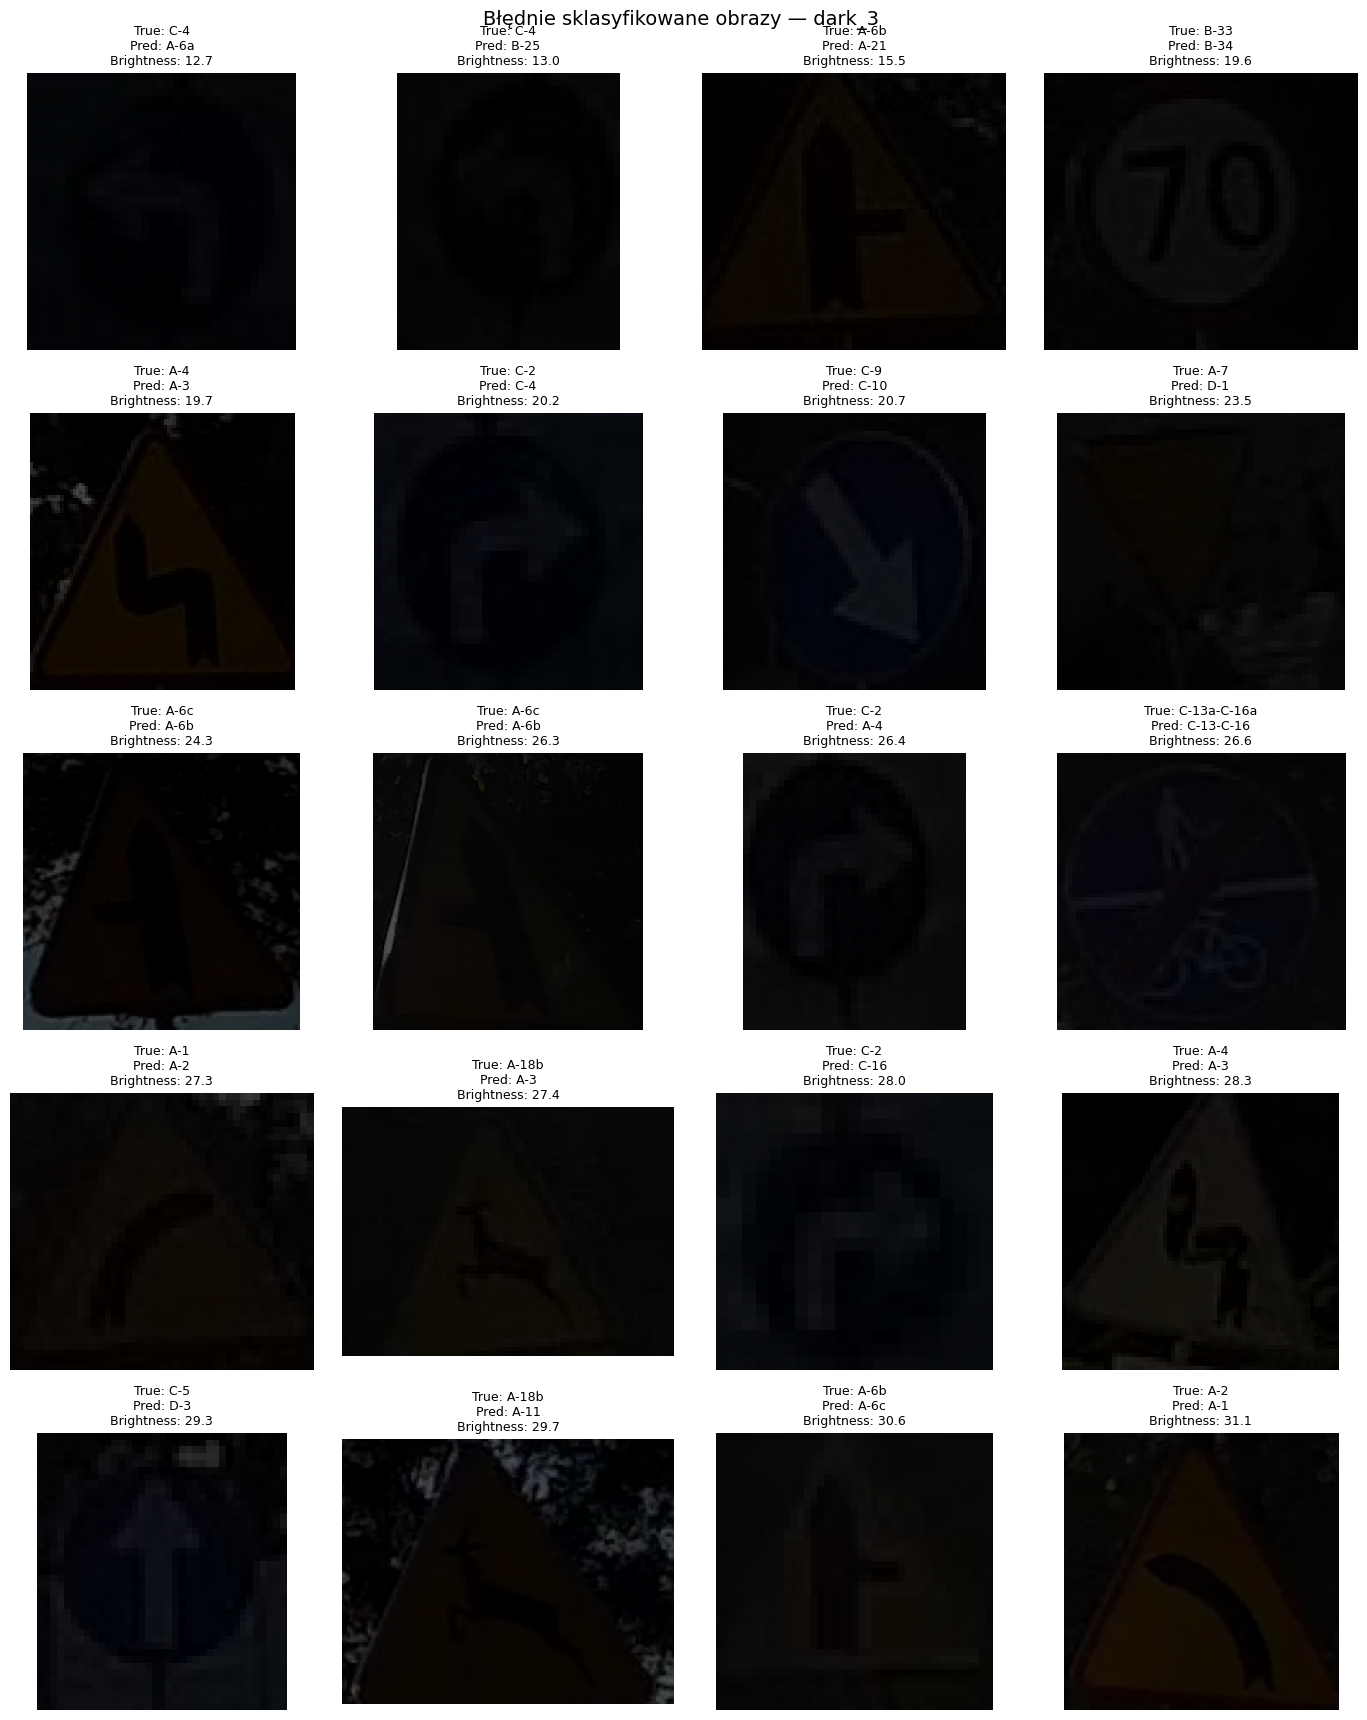

In [31]:
N_IMAGES = min(
    20,
    len(errors_df)
)


if N_IMAGES == 0:

    print(
        "Brak błędnych klasyfikacji."
    )

else:

    selected_errors = (
        errors_df
        .sort_values(
            "original_brightness"
        )
        .head(
            N_IMAGES
        )
    )


    columns = 4

    rows = math.ceil(
        N_IMAGES / columns
    )


    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            14,
            3.5 * rows,
        ),
    )


    axes = np.array(
        axes
    ).reshape(
        -1
    )


    for axis, (
        _,
        row,
    ) in zip(
        axes,
        selected_errors.iterrows(),
    ):

        image = Image.open(
            row[
                "path"
            ]
        ).convert(
            "RGB"
        )


        array = np.asarray(
            image,
            dtype=np.float32,
        )


        array = np.clip(
            array * 0.3,
            0,
            255,
        ).astype(
            np.uint8
        )


        dark_image = Image.fromarray(
            array
        )


        axis.imshow(
            dark_image
        )


        axis.set_title(
            (
                f"True: "
                f"{row['true_class']}\n"
                f"Pred: "
                f"{row['predicted_class']}\n"
                f"Brightness: "
                f"{row['original_brightness']:.1f}"
            ),
            fontsize=9,
        )


        axis.axis(
            "off"
        )


    for axis in axes[
        N_IMAGES:
    ]:

        axis.axis(
            "off"
        )


    fig.suptitle(
        "Błędnie sklasyfikowane obrazy — dark_3",
        fontsize=14,
    )


    plt.tight_layout()


    fig.savefig(
        FIGURES_DIR
        / "04_misclassified_dark3.png",
        dpi=250,
        bbox_inches="tight",
    )


    plt.show()

## 25. Analiza błędów dla `bright_3`

Analiza analogiczna do analizy `dark_3` jest wykonywana dla najsilniejszego wariantu zwiększonej jasności.

Pozwala to określić, czy prześwietlenie stanowi istotne źródło błędów końcowego pipeline'u.

In [32]:
bright3_result = next(
    result
    for result in test_results
    if result[
        "variant"
    ] == "bright_3"
)


y_true_bright3 = (
    bright3_result[
        "y_true"
    ]
)


y_pred_bright3 = (
    bright3_result[
        "y_pred"
    ]
)


bright3_report = pd.DataFrame(
    classification_report(
        y_true_bright3,
        y_pred_bright3,
        labels=list(
            range(
                len(class_codes)
            )
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


bright3_report = (
    bright3_report
    .iloc[
        :len(class_codes)
    ]
    .copy()
)


bright3_report[
    "class_code"
] = bright3_report.index


display(
    bright3_report.sort_values(
        "f1-score"
    ).head(20)
)

,precision,recall,f1-score,support,class_code
C-4,0.173913,0.400000,0.242424,10.0,C-4
B-18,0.200000,0.888889,0.326531,9.0,B-18
A-4,0.357143,0.312500,0.333333,32.0,A-4
A-20,0.263158,0.500000,0.344828,10.0,A-20
C-13a-C-16a,0.666667,0.333333,0.444444,6.0,C-13a-C-16a
C-2,0.571429,0.400000,0.470588,10.0,C-2
A-3,0.428571,0.562500,0.486486,32.0,A-3
B-21,0.615385,0.470588,0.533333,34.0,B-21
B-34,0.384615,0.882353,0.535714,17.0,B-34
A-6b,0.610390,0.546512,0.576687,86.0,A-6b


## 26. Zapis wyników końcowych

In [33]:
final_test_df.to_csv(
    METRICS_DIR
    / "final_pipeline_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)


dark_summary.to_csv(
    METRICS_DIR
    / "final_pipeline_dark_summary.csv",
    encoding="utf-8-sig",
)


cm_original_df.to_csv(
    METRICS_DIR
    / "final_pipeline_confusion_matrix_original.csv",
    encoding="utf-8-sig",
)


pd.DataFrame(
    cm_dark3,
    index=class_codes,
    columns=class_codes,
).to_csv(
    METRICS_DIR
    / "final_pipeline_confusion_matrix_dark3.csv",
    encoding="utf-8-sig",
)


dark3_report.to_csv(
    METRICS_DIR
    / "final_pipeline_dark3_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


bright3_report.to_csv(
    METRICS_DIR
    / "final_pipeline_bright3_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


errors_df.to_csv(
    METRICS_DIR
    / "final_pipeline_dark3_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

## 27. Podsumowanie końcowego eksperymentu

Końcowy pipeline został wytrenowany z wykorzystaniem ustalonych wcześniej komponentów:

- ResNet50,
- `WeightedRandomSampler`,
- augmentacja oświetleniowa,
- korekcja gamma γ = 1.5,
- Cross Entropy.

Końcowa ocena została wykonana na niezależnym zbiorze `test_final`.

Analiza obejmuje standardowe warunki obrazu, kontrolowane zaciemnienie oraz kontrolowane zwiększenie jasności.

Szczególne znaczenie ma porównanie skuteczności dla obrazu oryginalnego i wariantu `dark_3`, a także identyfikacja klas i obrazów powodujących największą liczbę błędów.

In [34]:
final_summary = {
    "experiment":
        "final_pipeline_training_and_test",

    "model":
        "ResNet50",

    "pretrained":
        PRETRAINED,

    "balancing_strategy":
        "weighted_sampler",

    "loss":
        "CrossEntropyLoss",

    "gamma":
        GAMMA_VALUE,

    "brightness_range":
        BRIGHTNESS_RANGE,

    "contrast_range":
        CONTRAST_RANGE,

    "augmentation_probability":
        AUGMENTATION_PROBABILITY,

    "frozen_epochs":
        FROZEN_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "frozen_learning_rate":
        FROZEN_LR,

    "fine_tune_learning_rate":
        FINE_TUNE_LR,

    "validation_results":
        validation_results,

    "test_results":
        final_test_df.to_dict(
            orient="records"
        ),

    "dark_summary":
        dark_summary.to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "final_pipeline_summary.json"
).write_text(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "final_pipeline_training_and_test",
  "model": "ResNet50",
  "pretrained": true,
  "balancing_strategy": "weighted_sampler",
  "loss": "CrossEntropyLoss",
  "gamma": 1.5,
  "brightness_range": [
    0.3,
    1.3
  ],
  "contrast_range": [
    0.8,
    1.2
  ],
  "augmentation_probability": 0.8,
  "frozen_epochs": 10,
  "fine_tune_epochs": 5,
  "frozen_learning_rate": 0.001,
  "fine_tune_learning_rate": 1e-05,
  "validation_results": {
    "accuracy": 0.9323248407643312,
    "macro_precision": 0.9279378192524976,
    "macro_recall": 0.9391786287487985,
    "macro_f1": 0.9302428707519097,
    "inference_time_seconds": 201.86491779999778
  },
  "test_results": [
    {
      "variant": "original",
      "factor": 1.0,
      "samples": 4298,
      "accuracy": 0.898324802233597,
      "macro_precision": 0.8779826532922392,
      "macro_recall": 0.8887177286635333,
      "macro_f1": 0.8754510627352157,
      "inference_time_seconds": 370.24385149999944
    },
    {
      "va

## 28. Szczegółowa analiza wpływu silnego prześwietlenia

Celem analizy jest określenie, czy spadek skuteczności dla wariantu `bright_3` wynika przede wszystkim z utraty informacji wizualnej spowodowanej prześwietleniem, czy z podobieństwa pomiędzy klasami znaków.

Analizie podlegają:
- błędy występujące wyłącznie po zwiększeniu jasności,
- jasność obrazów, które stały się błędnie klasyfikowane,
- najczęstsze pary błędnych klas,
- przykłady obrazów po zastosowaniu zwiększenia jasności ×2.0.

In [35]:
bright3_result = next(
    result
    for result in test_results
    if result["variant"] == "bright_3"
)

original_result = next(
    result
    for result in test_results
    if result["variant"] == "original"
)

y_true_bright3 = np.asarray(
    bright3_result["y_true"]
)

y_pred_bright3 = np.asarray(
    bright3_result["y_pred"]
)

y_pred_original = np.asarray(
    original_result["y_pred"]
)

assert len(test_df) == len(y_true_bright3)
assert len(y_true_bright3) == len(y_pred_bright3)
assert len(y_true_bright3) == len(y_pred_original)

print(
    "Liczba analizowanych obrazów:",
    len(test_df)
)

Liczba analizowanych obrazów: 4298


## 29. Błędy wprowadzone przez silne rozjaśnienie

Za szczególnie istotne uznaje się przypadki, w których obraz został poprawnie sklasyfikowany w warunku oryginalnym, ale po zwiększeniu jasności ×2.0 został sklasyfikowany błędnie.

Takie przypadki pozwalają lepiej ocenić rzeczywisty wpływ prześwietlenia na działanie modelu.

In [36]:
new_bright3_errors = (
    (y_pred_original == y_true_bright3)
    &
    (y_pred_bright3 != y_true_bright3)
)

new_error_indices = np.where(
    new_bright3_errors
)[0]

new_bright3_errors_df = test_df.iloc[
    new_error_indices
].copy()

new_bright3_errors_df[
    "true_class"
] = [
    idx_to_class[
        y_true_bright3[index]
    ]
    for index in new_error_indices
]

new_bright3_errors_df[
    "predicted_original"
] = [
    idx_to_class[
        y_pred_original[index]
    ]
    for index in new_error_indices
]

new_bright3_errors_df[
    "predicted_bright3"
] = [
    idx_to_class[
        y_pred_bright3[index]
    ]
    for index in new_error_indices
]

new_bright3_errors_df[
    "dataset_index"
] = new_error_indices

print(
    "Poprawne w original, błędne w bright_3:",
    len(new_bright3_errors_df)
)

display(
    new_bright3_errors_df[
        [
            "dataset_index",
            "true_class",
            "predicted_bright3",
            "path",
        ]
    ].head(20)
)

Poprawne w original, błędne w bright_3: 321


,dataset_index,true_class,predicted_bright3,path
24,24,A-1,A-2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
34,34,A-1,A-2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
36,36,A-1,A-2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
49,49,A-1,A-2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
51,51,A-11,A-2,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
105,105,A-15,A-21,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
130,130,A-16,D-6,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
168,168,A-17,A-12a,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
236,236,A-18b,A-16,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...
241,241,A-18b,A-14,C:\Users\Dell\Desktop\Kacper Błachowiak - prac...


## 30. Analiza błędów względem jasności obrazu

Dla obrazów błędnie sklasyfikowanych po zwiększeniu jasności analizowana jest jasność obrazu przed transformacją.

Pozwala to sprawdzić, czy błędy koncentrują się w obrazach, które już przed transformacją były jasne.

In [37]:
brightness_column = None

for candidate in [
    "mean_brightness",
    "brightness",
]:

    if candidate in test_df.columns:

        brightness_column = candidate

        break


if brightness_column is None:

    raise KeyError(
        "Nie znaleziono kolumny "
        "mean_brightness ani brightness "
        "w test_df."
    )


new_bright3_errors_df[
    "original_brightness"
] = [
    float(
        test_df.iloc[index][
            brightness_column
        ]
    )
    for index in new_error_indices
]

display(
    new_bright3_errors_df[
        [
            "dataset_index",
            "original_brightness",
            "true_class",
            "predicted_bright3",
        ]
    ].sort_values(
        "original_brightness",
        ascending=False,
    ).head(30)
)

,dataset_index,original_brightness,true_class,predicted_bright3
3125,3125,225.715378,D-1,A-30
1068,1068,225.646622,A-6e,A-12a
3882,3882,222.559784,D-53,G-3
49,49,221.416611,A-1,A-2
3153,3153,217.767151,D-1,A-7
3881,3881,217.333160,D-53,D-42
1297,1297,213.961563,B-2,B-1
1251,1251,213.155991,A-8,D-1
1296,1296,212.561325,B-2,B-1
1654,1654,211.382248,B-27,B-34


## 31. Statystyki jasności obrazów błędnie sklasyfikowanych po rozjaśnieniu

Porównano jasność oryginalnych obrazów, które:
1. pozostały poprawnie sklasyfikowane po zastosowaniu `bright_3`,
2. stały się błędnie sklasyfikowane po zastosowaniu `bright_3`.

Pozwala to ocenić, czy większa jasność wejściowa wiąże się z większym ryzykiem błędnej klasyfikacji.

In [38]:
original_brightness_all = (
    test_df[brightness_column]
    .astype(float)
    .to_numpy()
)

bright3_correct_mask = (
    y_pred_bright3 == y_true_bright3
)

bright3_error_mask = (
    y_pred_bright3 != y_true_bright3
)

brightness_summary = pd.DataFrame(
    {
        "group": [
            "bright_3 poprawne",
            "bright_3 błędne",
            "nowe błędy po bright_3",
        ],
        "samples": [
            int(bright3_correct_mask.sum()),
            int(bright3_error_mask.sum()),
            int(new_bright3_errors.sum()),
        ],
        "mean_brightness": [
            float(
                original_brightness_all[
                    bright3_correct_mask
                ].mean()
            ),
            float(
                original_brightness_all[
                    bright3_error_mask
                ].mean()
            ),
            float(
                original_brightness_all[
                    new_bright3_errors
                ].mean()
            ),
        ],
        "median_brightness": [
            float(
                np.median(
                    original_brightness_all[
                        bright3_correct_mask
                    ]
                )
            ),
            float(
                np.median(
                    original_brightness_all[
                        bright3_error_mask
                    ]
                )
            ),
            float(
                np.median(
                    original_brightness_all[
                        new_bright3_errors
                    ]
                )
            ),
        ],
    }
)

display(
    brightness_summary
)

,group,samples,mean_brightness,median_brightness
0,bright_3 poprawne,3703,112.859621,111.034119
1,bright_3 błędne,595,116.352162,114.941994
2,nowe błędy po bright_3,321,131.186825,133.730896


## 32. Rozkład jasności obrazów błędnie sklasyfikowanych

Wykres przedstawia rozkład jasności oryginalnych obrazów dla przypadków, które pozostały poprawne oraz dla przypadków błędnie sklasyfikowanych po zastosowaniu `bright_3`.

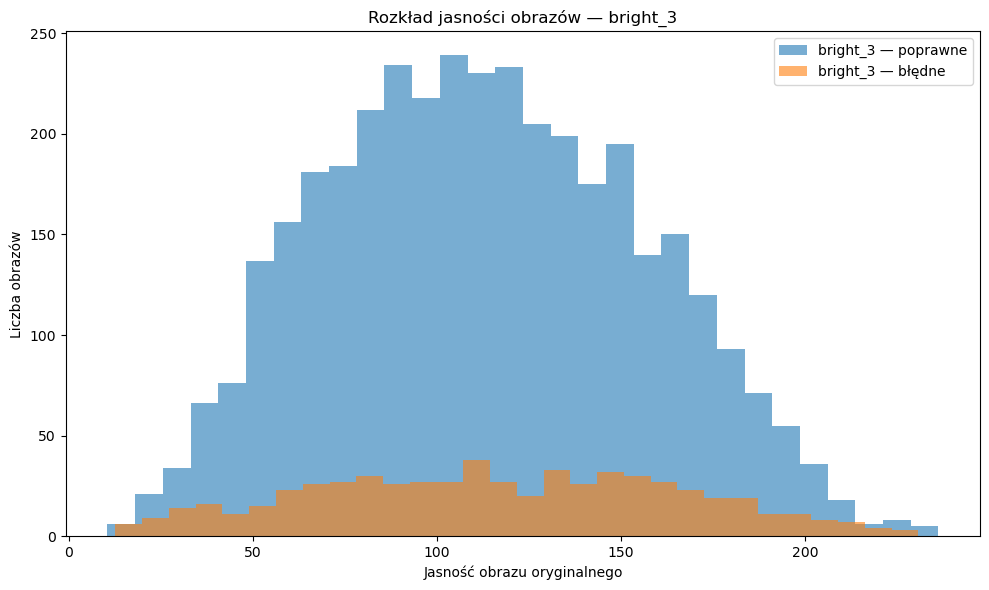

In [39]:
plt.figure(
    figsize=(10, 6)
)

plt.hist(
    original_brightness_all[
        bright3_correct_mask
    ],
    bins=30,
    alpha=0.6,
    label="bright_3 — poprawne",
)

plt.hist(
    original_brightness_all[
        bright3_error_mask
    ],
    bins=30,
    alpha=0.6,
    label="bright_3 — błędne",
)

plt.xlabel(
    "Jasność obrazu oryginalnego"
)

plt.ylabel(
    "Liczba obrazów"
)

plt.title(
    "Rozkład jasności obrazów — bright_3"
)

plt.legend()

plt.tight_layout()

plt.show()

## 33. Najczęstsze pary błędnych klas dla `bright_3`

Analiza najczęstszych par błędów pozwala określić, czy model traci informacje charakterystyczne dla znaku, czy przede wszystkim myli znaki o podobnym wyglądzie.

In [40]:
bright3_error_pairs = []

for true_index, pred_index in zip(
    y_true_bright3,
    y_pred_bright3,
):

    if true_index != pred_index:

        bright3_error_pairs.append(
            (
                idx_to_class[true_index],
                idx_to_class[pred_index],
            )
        )


bright3_error_pairs_df = (
    pd.DataFrame(
        bright3_error_pairs,
        columns=[
            "true_class",
            "predicted_class",
        ],
    )
    .value_counts()
    .reset_index(
        name="errors"
    )
)

display(
    bright3_error_pairs_df.head(20)
)

,true_class,predicted_class,errors
0,C-9,C-10,86
1,A-6b,A-6c,27
2,B-33,B-18,23
3,C-10,C-9,23
4,A-4,A-3,21
5,A-2,A-1,18
6,B-21,B-22,17
7,A-6c,A-6b,17
8,A-3,A-4,14
9,B-33,B-34,12


## 34. Klasy najbardziej podatne na silne prześwietlenie

Aby odróżnić problem związany z prześwietleniem od ogólnej trudności klasy, porównano F1-score dla obrazu oryginalnego i dla `bright_3`.

Duży spadek F1-score wskazuje na klasę szczególnie podatną na zwiększenie jasności.

In [41]:
original_report = pd.DataFrame(
    classification_report(
        original_result["y_true"],
        original_result["y_pred"],
        labels=list(
            range(len(class_codes))
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T

bright3_report_compare = pd.DataFrame(
    classification_report(
        y_true_bright3,
        y_pred_bright3,
        labels=list(
            range(len(class_codes))
        ),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


class_comparison_df = pd.DataFrame(
    {
        "class_code": class_codes,
        "original_f1": [
            original_report.loc[
                class_code,
                "f1-score",
            ]
            for class_code in class_codes
        ],
        "bright3_f1": [
            bright3_report_compare.loc[
                class_code,
                "f1-score",
            ]
            for class_code in class_codes
        ],
    }
)

class_comparison_df[
    "f1_drop"
] = (
    class_comparison_df[
        "original_f1"
    ]
    -
    class_comparison_df[
        "bright3_f1"
    ]
)

display(
    class_comparison_df.sort_values(
        "f1_drop",
        ascending=False,
    ).head(20)
)

,class_code,original_f1,bright3_f1,f1_drop
26,B-18,0.642857,0.326531,0.316327
35,B-34,0.829268,0.535714,0.293554
10,A-20,0.636364,0.344828,0.291536
25,B-1,1.000000,0.727273,0.272727
49,C-13a,1.000000,0.727273,0.272727
33,B-27,0.912281,0.654545,0.257735
37,B-41,1.000000,0.750000,0.250000
44,B-9,0.971429,0.733333,0.238095
91,G-3,1.000000,0.769231,0.230769
38,B-42,0.875000,0.666667,0.208333


## 35. Wizualizacja nowych błędów po silnym rozjaśnieniu

Przedstawiono przykłady obrazów, które były poprawnie klasyfikowane w warunku oryginalnym, ale zostały błędnie sklasyfikowane po zwiększeniu jasności ×2.0.

Taka analiza pozwala bezpośrednio ocenić, czy zwiększenie jasności doprowadziło do utraty informacji wizualnej.

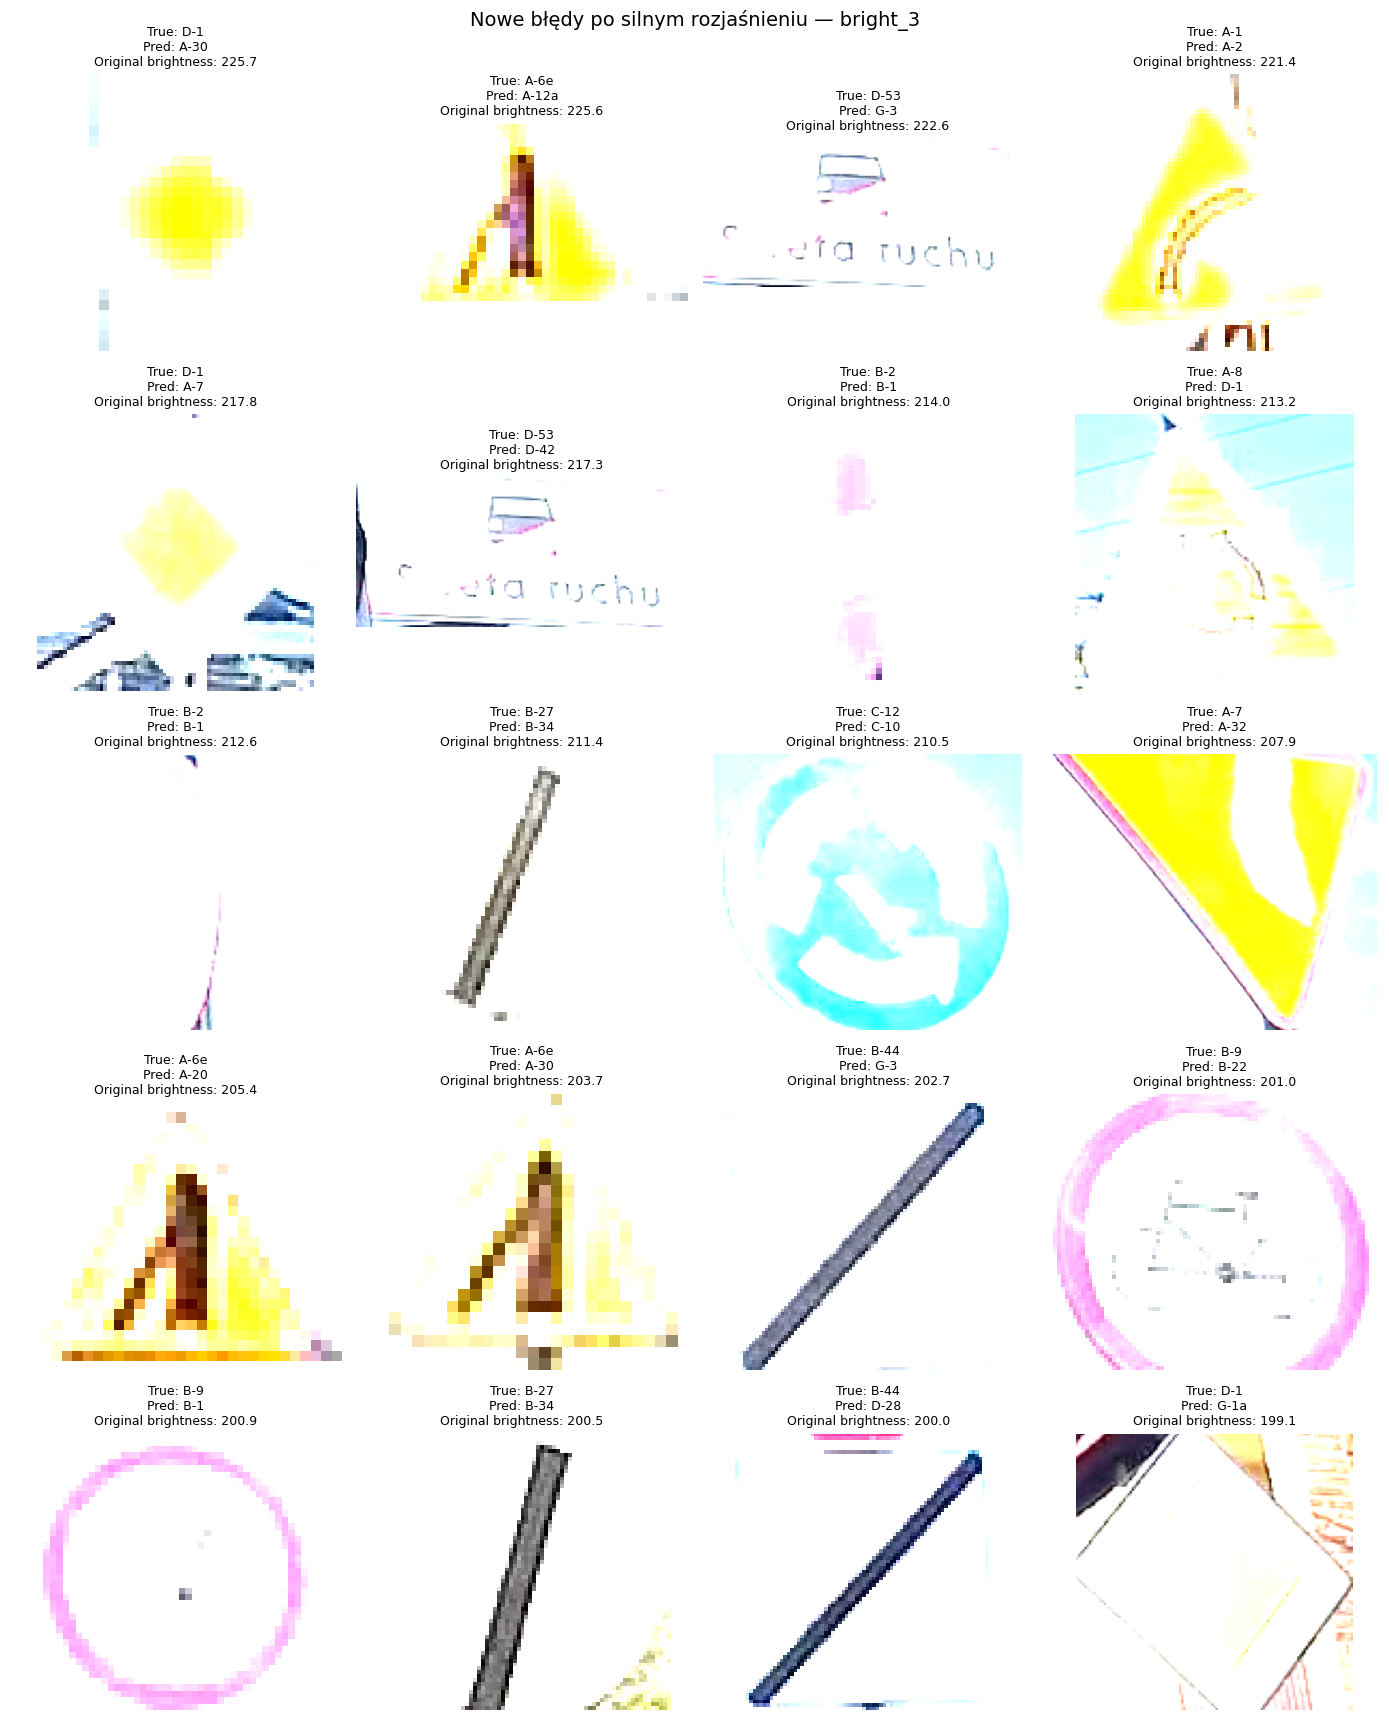

In [42]:
from PIL import ImageEnhance


N_IMAGES = min(
    20,
    len(new_bright3_errors_df)
)


if N_IMAGES == 0:

    print(
        "Nie znaleziono nowych błędów "
        "wprowadzonych przez bright_3."
    )

else:

    selected_errors = (
        new_bright3_errors_df
        .sort_values(
            "original_brightness",
            ascending=False,
        )
        .head(N_IMAGES)
    )

    columns = 4

    rows = math.ceil(
        N_IMAGES / columns
    )

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            14,
            3.5 * rows,
        ),
    )

    axes = np.asarray(
        axes
    ).reshape(-1)

    for axis, (_, row) in zip(
        axes,
        selected_errors.iterrows(),
    ):

        image = Image.open(
            row["path"]
        ).convert(
            "RGB"
        )

        bright_image = (
            ImageEnhance.Brightness(
                image
            ).enhance(
                2.0
            )
        )

        axis.imshow(
            bright_image
        )

        axis.set_title(
            (
                f"True: "
                f"{row['true_class']}\n"
                f"Pred: "
                f"{row['predicted_bright3']}\n"
                f"Original brightness: "
                f"{row['original_brightness']:.1f}"
            ),
            fontsize=9,
        )

        axis.axis(
            "off"
        )

    for axis in axes[
        N_IMAGES:
    ]:

        axis.axis(
            "off"
        )

    fig.suptitle(
        "Nowe błędy po silnym rozjaśnieniu — bright_3",
        fontsize=14,
    )

    plt.tight_layout()

    fig.savefig(
        FIGURES_DIR
        / "05_new_errors_bright3.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

## 36. Wnioski z analizy silnego prześwietlenia

Na podstawie wyników porównano:
- skuteczność modelu dla obrazu oryginalnego i `bright_3`,
- liczbę błędów powstałych po zwiększeniu jasności,
- rozkład jasności obrazów błędnie sklasyfikowanych,
- najczęstsze pary błędnych klas,
- klasy charakteryzujące się największym spadkiem F1-score,
- wizualne przykłady błędów.

Analiza pozwala rozstrzygnąć, czy degradacja wyników dla `bright_3` wynika głównie z prześwietlenia obrazu, czy z trudności rozróżniania podobnych klas.

In [43]:
bright3_summary = {
    "original_macro_f1": float(
        original_result[
            "macro_f1"
        ]
    ),
    "bright3_macro_f1": float(
        bright3_result[
            "macro_f1"
        ]
    ),
    "macro_f1_drop": float(
        original_result[
            "macro_f1"
        ]
        -
        bright3_result[
            "macro_f1"
        ]
    ),
    "bright3_total_errors": int(
        bright3_error_mask.sum()
    ),
    "new_errors_after_brightening": int(
        new_bright3_errors.sum()
    ),
    "mean_original_brightness_correct": float(
        original_brightness_all[
            bright3_correct_mask
        ].mean()
    ),
    "mean_original_brightness_errors": float(
        original_brightness_all[
            bright3_error_mask
        ].mean()
    ),
    "mean_original_brightness_new_errors": float(
        original_brightness_all[
            new_bright3_errors
        ].mean()
    ),
}

print(
    json.dumps(
        bright3_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "original_macro_f1": 0.8754510627352157,
  "bright3_macro_f1": 0.8204520954071318,
  "macro_f1_drop": 0.05499896732808385,
  "bright3_total_errors": 595,
  "new_errors_after_brightening": 321,
  "mean_original_brightness_correct": 112.85962112600855,
  "mean_original_brightness_errors": 116.35216155813522,
  "mean_original_brightness_new_errors": 131.186825083795
}


In [44]:
new_bright3_errors_df.to_csv(
    METRICS_DIR
    / "final_pipeline_bright3_new_errors.csv",
    index=False,
    encoding="utf-8-sig",
)

bright3_error_pairs_df.to_csv(
    METRICS_DIR
    / "final_pipeline_bright3_error_pairs.csv",
    index=False,
    encoding="utf-8-sig",
)

class_comparison_df.to_csv(
    METRICS_DIR
    / "final_pipeline_bright3_class_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

brightness_summary.to_csv(
    METRICS_DIR
    / "final_pipeline_bright3_brightness_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

(
    METRICS_DIR
    / "final_pipeline_bright3_analysis_summary.json"
).write_text(
    json.dumps(
        bright3_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(
    "Zapisano dodatkowe wyniki analizy bright_3."
)

Zapisano dodatkowe wyniki analizy bright_3.
